# TorchSig Models v1.0 in 10 minutes

Let's walk through a complete RF-classification workflow: generate synthetic signals, train a model, inspect its performance, reload a checkpoint, and then connect those ideas to `solve_challenge.ipynb`.

We'll train the **1-D IQ EfficientNet-B0 included in `torchsig-models` v1.0.0**. At the end, we'll switch to the released XCiT checkpoint used by the challenge. Both models consume two-channel IQ data. The spectrogram shown below is only a visualization—v1.0.0 does not include the later `spectrogram_models` package.

The quick cells are already executed so this notebook is easy to browse. Dataset generation and training are opt-in because they take longer. A separate `speaker_notes.txt` contains the timed presentation script.

## 1. Get the notebook ready

Start by running the setup cell once. It checks the current kernel and installs only what is missing. If `torchsig-models` is unavailable, it installs the v1.0.0 tag directly from GitHub; there is no PyPI package for this release yet. If Colab still reports a missing import afterward, restart the runtime and continue from the import cell.

Working from a clone instead? You can use `python -m pip install -r requirements.txt`, or `python -m pip install -e ..` when you want edits to the repository to appear immediately.

> We'll keep this experiment under `runs/v1_iq_tutorial`. That dedicated path matters: TorchSig reuses static datasets, and we do not want to mistake an older spectrogram dataset for IQ data. Colab storage is temporary, so download any checkpoint you want to keep.

In [1]:
# Run this setup cell once in Colab or a local Jupyter kernel.
import importlib.util
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules
requirements = []
if importlib.util.find_spec('torchsig_models') is None:
    requirements.append('git+https://github.com/TorchDSP/torchsig-models.git@v1.0.0')
if importlib.util.find_spec('matplotlib') is None:
    requirements.append('matplotlib>=3.7')
if importlib.util.find_spec('yaml') is None:
    requirements.append('PyYAML>=6.0')

if requirements:
    print('Installing missing packages:', ', '.join(requirements))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *requirements])
    print('Installation complete. Restart the kernel if an import still fails.')
else:
    print('All notebook dependencies are already installed.')

All notebook dependencies are already installed.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

import torchsig_models
from torchsig.datasets.datasets import StaticTorchSigDataset, TorchSigDatasetConfig
from torchsig.transforms.transforms import ComplexTo2D
from torchsig.utils.defaults import TorchSigDefaults
from torchsig.utils.file_handlers import SigMFReader
from torchsig_models.models import XCiTClassifier
from torchsig_models.models.iq_models.efficientnet.efficientnet1d_inference import efficientnet1d_inference
from torchsig_models.models.iq_models.efficientnet.efficientnet1d_train import train_efficientnet_iq
from torchsig_models.utils.training import evaluate_classifier, set_deterministic

assert torchsig_models.__version__ == '1.0.0'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TRAINING = False  # Set True when you want to generate data and train.
RUN_INFERENCE = False  # Set True only after selecting the intended checkpoint.
RUNS = Path('runs/v1_iq_tutorial')
set_deterministic(2026)
print(f'TorchSig Models {torchsig_models.__version__}; device={DEVICE}')

TorchSig Models 1.0.0; device=cuda


### First, what does the model actually see?

An RF recording is a sequence of complex samples. We split each sample into its real, in-phase component (**I**) and imaginary, quadrature component (**Q**). Those are the two traces in the first plot.

The second plot turns the same signal into a spectrogram, which makes the rising frequency easy for us to recognize. It is a useful diagnostic, but don't feed it to this model: the v1.0 EfficientNet and XCiT examples both expect IQ tensors shaped like `[batch, 2, samples]`.

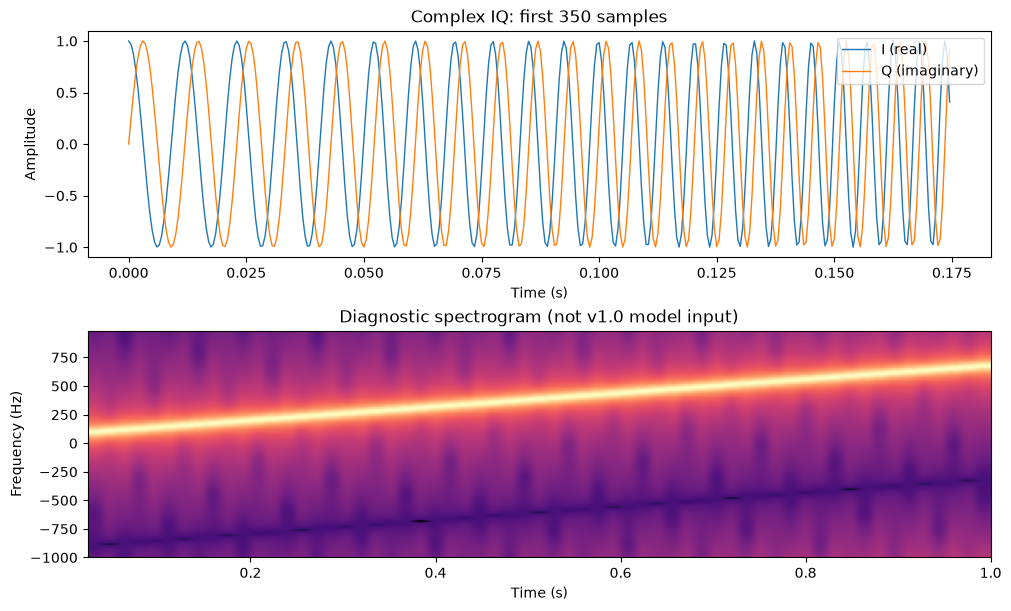

In [3]:
sample_rate = 2_000
time = np.arange(2_048) / sample_rate
frequency_slope = (700 - 80) / time[-1]
phase = 2 * np.pi * (80 * time + 0.5 * frequency_slope * time**2)
example_iq = np.exp(1j * phase)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
axes[0].plot(time[:350], example_iq.real[:350], label='I (real)', linewidth=1)
axes[0].plot(time[:350], example_iq.imag[:350], label='Q (imaginary)', linewidth=1)
axes[0].set(title='Complex IQ: first 350 samples', xlabel='Time (s)', ylabel='Amplitude')
axes[0].legend(loc='upper right')
axes[1].specgram(example_iq, NFFT=128, Fs=sample_rate, noverlap=96, cmap='magma')
axes[1].set(title='Diagnostic spectrogram (not v1.0 model input)', xlabel='Time (s)', ylabel='Frequency (Hz)')
plt.show()

## 2. Tell TorchSig what to generate

Now we'll describe our dataset once and reuse that description for three independent splits. A `TorchSigDatasetConfig` controls things such as capture length, sample rate, SNR, signal duration, and output representation. Changing the seed for each split gives us different examples for training, validation, and testing.

To keep the demo approachable, we'll distinguish just `tone` from `lfm-radar`. Every capture contains one long, high-SNR signal, and `output_representation='iq'` asks TorchSig to return two-channel IQ. This is a pipeline check, not a realistic benchmark; a production experiment should cover the classes, impairments, and SNR range it will encounter.

In [4]:
SIGNALS = ['tone', 'lfm-radar']

def make_config(length: int, seed: int) -> TorchSigDatasetConfig:
    metadata = TorchSigDefaults().default_dataset_metadata.copy()
    metadata.update({
        'sample_rate': 10_000_000,
        'num_iq_samples_dataset': 4096,
        'fft_size': 64,
        'fft_stride': 64,
        'num_signals_min': 1,
        'num_signals_max': 1,
        'cochannel_overlap_probability': 0.0,
        'snr_db_min': 20.0,
        'snr_db_max': 40.0,
        'noise_power_db': 0.0,
        'signal_duration_in_samples_min': 3600,
        'signal_duration_in_samples_max': 4096,
        'bandwidth_min': 1_500_000,
        'bandwidth_max': 2_000_000,
        'signal_center_freq_min': -2_500_000,
        'signal_center_freq_max': 2_499_999,
        'frequency_min': -2_500_000,
        'frequency_max': 2_499_999,
    })
    return TorchSigDatasetConfig(
        dataset_id='efficientnet_iq_tutorial', dataset_length=length, seed=seed,
        impairment_level=0, output_representation='iq',
        output_spectrogram_fft=64,  # Required by the config schema; unused for IQ output.
        signal_sampling_mode='per_signal',
        dataset_metadata=metadata, target_labels=['class_index'],
    )

train_cfg = make_config(256, 5101)
val_cfg = make_config(128, 5102)
test_cfg = make_config(128, 5103)
print({name: cfg.dataset_length for name, cfg in [('train', train_cfg), ('val', val_cfg), ('test', test_cfg)]})

{'train': 256, 'val': 128, 'test': 128}


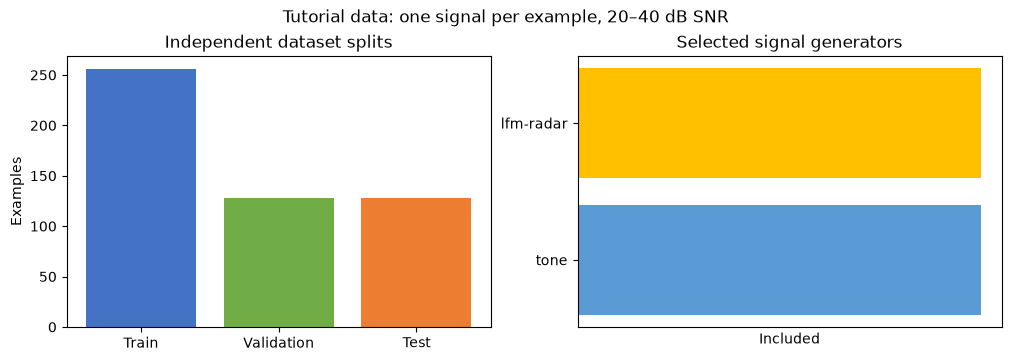

In [5]:
# A quick visual check of the experiment before generating any large files.
split_sizes = {'Train': train_cfg.dataset_length, 'Validation': val_cfg.dataset_length, 'Test': test_cfg.dataset_length}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].bar(list(split_sizes), list(split_sizes.values()), color=['#4472C4', '#70AD47', '#ED7D31'])
axes[0].set(title='Independent dataset splits', ylabel='Examples')
axes[1].barh(SIGNALS, [1] * len(SIGNALS), color=['#5B9BD5', '#FFC000'])
axes[1].set(title='Selected signal generators', xlabel='Included')
axes[1].set_xticks([])
fig.suptitle('Tutorial data: one signal per example, 20–40 dB SNR')
plt.show()

## 3. Let the training API do the plumbing

Here is the main handoff. `train_efficientnet_iq` creates the static datasets, applies `ComplexTo2D`, builds EfficientNet-B0, trains it, saves the best validation-F1 checkpoint, and evaluates the final model on the test split. We still get the useful pieces back—the PyTorch model, dataloaders, metric trackers, parameter count, and dataset location—so we can inspect or extend the workflow afterward.

Set `RUN_TRAINING = True` near the top when you're ready. Eight epochs and a few hundred examples are enough to exercise the API, but not enough to establish a serious RF result. Full-scale TorchSig datasets can also consume hundreds of gigabytes, so scale deliberately.

> A quick warning about the cache: `overwrite=False` reuses an existing static dataset. If you change the representation, transforms, sample length, or classes, give the experiment a new `dataset_id` or intentionally set `overwrite=True`. For this notebook, a batch should be `[batch, 2, samples]`. A shape like `[batch, frequency, time]` means you picked up a cached spectrogram dataset.

In [6]:
params = {
    'batch_size': 16, 'max_epochs': 8, 'learning_rate': 3e-3,
    'weight_decay': 1e-5, 'drop_path': 0.0, 'drop_rate': 0.0,
    'label_smoothing': 0.0, 'normalize': False,
}

if RUN_TRAINING:
    result = train_efficientnet_iq(
        train_cfg, val_cfg, test_cfg, params,
        checkpoint_dir=RUNS / 'checkpoints',
        metrics_dir=RUNS / 'metrics',
        dataset_root=RUNS / 'datasets',
        overwrite=False, model_name='efficientnet_b0',
        signal_generators=SIGNALS,
    )
    test_accuracy = result['test_metrics'].history['accuracy'][-1]
    print(f"parameters={result['num_params']:,}")
    print(f'test accuracy={test_accuracy:.2%}')
    print(f"data={result['data_info']['root']}")
else:
    print('Training skipped; set RUN_TRAINING=True to run this section.')

Training skipped; set RUN_TRAINING=True to run this section.


### Look past the final accuracy

A single accuracy number is useful, but it can hide an imbalanced dataset or one class that consistently fails. The TorchSig Models tracker records loss, accuracy, precision, recall, F1, and confusion matrices, and saves the tables beneath `metrics/`. The plots below make it easier to see whether training improved and whether validation kept pace.

For a real RF evaluation, break results down by class and SNR as well. And remember: strong performance on clean synthetic examples is not proof that the model will work on a radio capture with different filtering, sample rate, interference, or channel effects.

In [7]:
if RUN_TRAINING:
    print('metric fields:', sorted(result['test_metrics'].history))
    # Re-evaluate explicitly when testing a changed criterion or model.
    repeated = evaluate_classifier(
        result['model'], result['test_loader'], DEVICE, result['num_classes']
    )
    print(f"repeated accuracy={repeated.history['accuracy'][-1]:.2%}")

    tracked = result['metrics']
    epochs = range(1, len(tracked.train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].plot(epochs, tracked.train_losses, marker='o', label='train')
    axes[0].plot(epochs, tracked.val_losses, marker='o', label='validation')
    axes[0].set(title='Loss by epoch', xlabel='Epoch', ylabel='Cross-entropy loss')
    axes[1].plot(epochs, tracked.train_accuracies, marker='o', label='train')
    axes[1].plot(epochs, tracked.val_accuracies, marker='o', label='validation')
    axes[1].axhline(1 / len(SIGNALS), color='gray', linestyle='--', label='two-class chance')
    axes[1].set(title='Accuracy by epoch', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1.02))
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    plt.show()
else:
    print('Metric plots appear here after RUN_TRAINING=True completes.')

Metric plots appear here after RUN_TRAINING=True completes.


## 4. Reload the model for inference

A checkpoint is only useful if we rebuild the same architecture and preprocessing around it. `efficientnet1d_inference` does that for a static IQ dataset, using the checkpoint plus a small parameter YAML.

There is one v1.0 detail worth handling carefully. Restricting `signal_generators` changes which examples are generated, but the released training helper can still build an output for every class in the installed TorchSig registry. That is why a two-signal experiment may produce a checkpoint with 69 outputs. Rather than guessing, the next cell reads the classifier tensor from the checkpoint and uses its actual size.

In [8]:
# Example after training; select the checkpoint you intend to deploy.
checkpoints = sorted((RUNS / 'checkpoints').glob('best-*.ckpt'))
checkpoint = checkpoints[-1] if checkpoints else None
static_test_root = RUNS / 'datasets' / 'efficientnet_iq_tutorial' / 'test'
if RUN_INFERENCE and checkpoint is not None:
    params_file = RUNS / 'efficientnet_b0_params.yaml'
    params_file.write_text(yaml.safe_dump(params), encoding='utf-8')
    checkpoint_data = torch.load(checkpoint, map_location='cpu', weights_only=False)
    checkpoint_state = checkpoint_data.get('state_dict', checkpoint_data)
    classifier_weights = [
        value for key, value in checkpoint_state.items()
        if key.endswith('classifier.weight')
    ]
    if len(classifier_weights) != 1:
        raise ValueError('Could not identify one classifier.weight tensor in the checkpoint.')
    checkpoint_num_classes = int(classifier_weights[0].shape[0])
    print(f'Checkpoint output classes: {checkpoint_num_classes}')
    accuracy = efficientnet1d_inference(
        root=static_test_root, checkpoint_path=checkpoint,
        params_path=params_file, batch_size=16, num_workers=0,
        num_classes=checkpoint_num_classes,
        model_name='efficientnet_b0',
    )
elif checkpoint is None:
    print(f"Run training first; no checkpoint found under {RUNS / 'checkpoints'}.")
else:
    print(f'Checkpoint found at {checkpoint}; set RUN_INFERENCE=True to evaluate it.')

Run training first; no checkpoint found under runs/v1_iq_tutorial/checkpoints.


### Save the pieces you'll need later

The best validation-F1 checkpoint lands in `runs/v1_iq_tutorial/checkpoints`. If you're in Colab, run the next cell before the runtime disappears; it downloads both the checkpoint and the parameter YAML. In a later session, upload both files and pass their paths to `efficientnet1d_inference`. A dependable model artifact should also travel with its architecture name, preprocessing recipe, and ordered class names.

The challenge uses a separate pretrained XCiT model. You can fetch it from the [TorchSig Models v1.0.0 release](https://github.com/TorchDSP/torchsig-models/releases/download/v1.0.0/xcit_narrowband_v1.0.0.ckpt), although `solve_challenge.ipynb` will download it for you when needed.

In [9]:
trained_checkpoints = sorted((RUNS / 'checkpoints').glob('best-*.ckpt'))
if not trained_checkpoints:
    print('No trained checkpoint yet. Set RUN_TRAINING=True and run the training cell first.')
else:
    trained_checkpoint = trained_checkpoints[-1]
    saved_params = RUNS / 'efficientnet_b0_params.yaml'
    saved_params.write_text(yaml.safe_dump(params), encoding='utf-8')
    if IN_COLAB:
        from google.colab import files
        files.download(str(trained_checkpoint))
        files.download(str(saved_params))
    else:
        print(f'Checkpoint ready to copy: {trained_checkpoint.resolve()}')
        print(f'Parameters ready to copy: {saved_params.resolve()}')

No trained checkpoint yet. Set RUN_TRAINING=True and run the training cell first.


## 5. Apply the same ideas to the challenge

The challenge swaps in real SigMF files and the released XCiT checkpoint, but the inference recipe is familiar. `SigMFReader` loads each complex capture. We sort the paths and avoid shuffling so the answer stays in capture order. Then we split real and imaginary values into a `[batch, 2, samples]` float tensor, just like the IQ model input above.

After loading the checkpoint, call `eval()` and run the forward pass inside `torch.inference_mode()`. The largest logit gives a class index, but that number only becomes meaningful when it is mapped through the exact vocabulary used during training. This released checkpoint has 57 outputs in the historical TorchSig 2.1.1 order—not necessarily the order exposed by a newer installation.

So the four things to double-check are simple: capture order, IQ shape, checkpoint compatibility, and historical class order. Once those agree, the flag is just the first letter of each predicted class.

In [10]:
# Compact inference pattern used by solve_challenge.ipynb.
def classify_xcit(iq_samples: np.ndarray, checkpoint: Path, class_names: list[str]):
    model = XCiTClassifier.load_from_checkpoint(checkpoint, map_location=DEVICE)
    model.to(DEVICE).eval()
    # Equivalent to TorchSig ComplexTo2D: complex [B, N] -> real [B, 2, N].
    x = torch.from_numpy(np.stack((iq_samples.real, iq_samples.imag), axis=1))
    with torch.inference_mode():
        scores = model(x.to(DEVICE, dtype=torch.float32)).softmax(dim=1).cpu()
    confidence, index = scores.max(dim=1)
    names = [class_names[i] for i in index.tolist()]
    return names, confidence

# The solve notebook supplies CAPTURE_DIR, checkpoint download, and exact
# CLASS_NAMES_V211. Its data-loading core is:
# paths = sorted(CAPTURE_DIR.glob('capture_*.sigmf-meta'))
# captures = StaticTorchSigDataset(
#     root=CAPTURE_DIR, file_handler_class=SigMFReader, target_labels=[]
# )
# names, confidence = classify_xcit(iq_batch, CHECKPOINT, CLASS_NAMES_V211)
# answer = ''.join(name[0] for name in names).upper()

## 6. Where that leaves us

We started with a signal distribution, generated independent static splits, trained through the TorchSig Models API, inspected more than one metric, and reloaded a checkpoint using the architecture it was trained with. The common thread is consistency: the same sample format, preprocessing, model shape, and label order must follow the weights into inference.

That is also everything `solve_challenge.ipynb` needs: sorted SigMF captures, two-channel IQ, the released XCiT checkpoint, its historical labels, and the first letter of each prediction.